house price prediction 


In [13]:
# 1. Gerekli Kütüphanelerin Yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  r2_score
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans

2. VERI SETININ YÜKLENMESI

In [4]:
df = pd.read_csv("C:/Users/gulizar_elhalil/OneDrive/Desktop/house_price_prediction/house_prices_practice.csv")
df.head(10)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656
5,6,10,680,1,2480,1950,2,1,13081,213952
6,7,3,1106,2,1096,1962,1,4,11153,145539
7,8,7,3670,1,437,2000,2,5,4989,350830
8,9,8,1199,2,1653,2005,1,5,14040,275955
9,10,5,1492,1,2175,2011,1,2,11218,211664


Değişkenler:
Id → Her ev için benzersiz kimlik numarası
OverallQual → Evin genel kalite puanı (1–10 arası)
GrLivArea → Yaşam alanı (zemin üstü m²/ft²)
GarageCars → Garaj kapasitesi (araç sayısı)
TotalBsmtSF → Bodrum alanı (m²/ft²)
YearBuilt → Evin inşa edildiği yıl
FullBath → Tam banyo sayısı
BedroomAbvGr → Zemin üstü yatak odası sayısı
LotArea → Arsa büyüklüğü (m²/ft²)
SalePrice → Ev satış fiyatı (hedef değişken)

3. VERI HAKKINDA GENEL BILGI 

In [5]:
df.info()                 # Veri tipleri ve sütun bilgisi
df.describe(include="all")# İstatistiksel özet
df.isnull().sum()         # Eksik değer kontrolü
df.shape                  # Satır ve sütun sayısı

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


(300, 10)

4. VERI TEMIZLEME

In [6]:
df = df.drop_duplicates()                # Tekrar eden satırları sil
df.fillna(df.mean(), inplace=True)       # Eksik sayısal değerleri ortalama ile doldur

5. KEŞİFSEL VERİ ANALIZI (EDA)

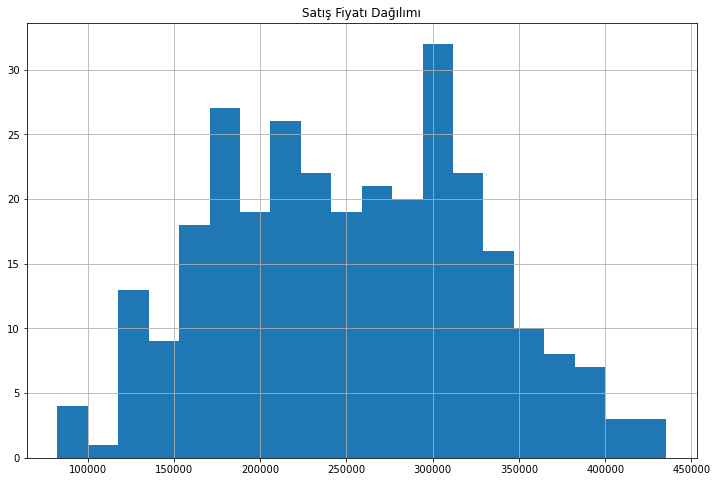

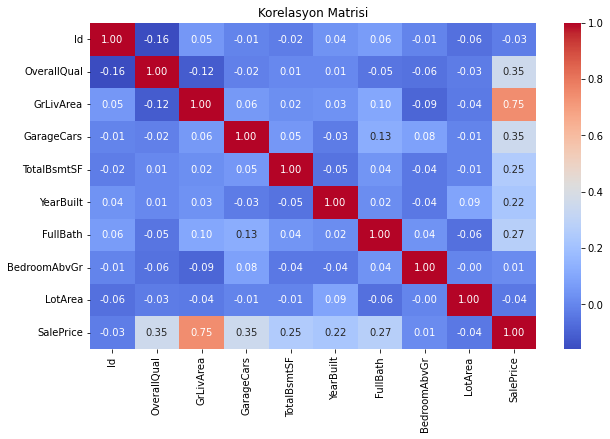

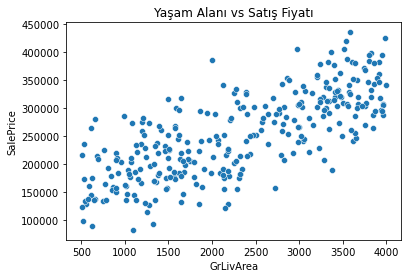

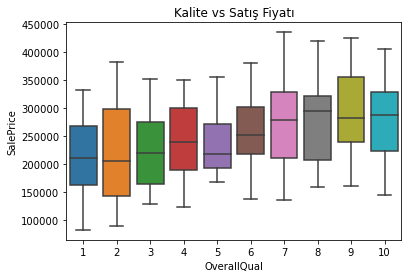

In [7]:
# Hedef değişkenin dağılımı
df["SalePrice"].hist(bins=20, figsize=(12, 8))
plt.title("Satış Fiyatı Dağılımı")
plt.show()

# Korelasyon Isı Haritası
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")
plt.show()
#annot=True → Hücrelerin içine sayısal değerleri yazar.
#cmap="coolwarm" → Renk paletini belirler.
#fmt=".2f" → Sayıları iki ondalık basamakla gösterir.

# Önemli değişkenlerle ilişkiler
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title("Yaşam Alanı vs Satış Fiyatı")
plt.show()

sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title("Kalite vs Satış Fiyatı")
plt.show()

6. ÖZELLIK SEÇIMI VE OLCEKLEME

In [8]:
X = df[['OverallQual','GrLivArea','GarageCars','TotalBsmtSF','YearBuilt','FullBath','BedroomAbvGr','LotArea']]
y = df['SalePrice']

# Min-Max ölçekleme
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Eğitim ve test seti ayırma
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


7. MODELLERIN EĞİTİLMESİ VE DEĞENDİRİLMESİ

In [9]:
# Doğrusal Regresyon
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", mean_squared_error(y_test, y_pred_rf, squared=False))# RMSE:Ortalama hata büyüklüğü


Linear Regression R2: 0.9724369952260821
Linear Regression RMSE: 12505.459264618985
Random Forest R2: 0.8679710467264632
Random Forest RMSE: 27369.757897632226


8. ÖZELLİK ÖNEMLERİ 

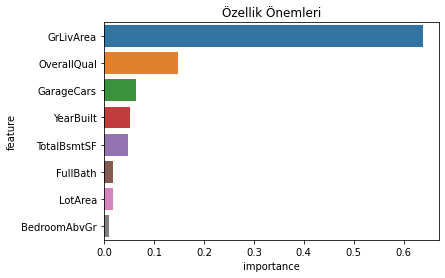

In [24]:
# HANGI DEĞİŞKENLER DAHA ÖNEMLİ
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title("Özellik Önemleri")
plt.show()


9. K-MEAN KUMELEME

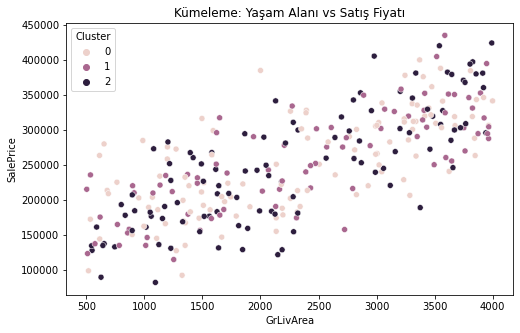

In [25]:
# EVLER BNEZER ÖZELIKLERINE GÖRE KÜMELERE AYILIYOR.
kmeans = KMeans(n_clusters=3, random_state=0)
df["Cluster"] = kmeans.fit_predict(X)

plt.figure(figsize=(8,5))
sns.scatterplot(x="GrLivArea", y="SalePrice", hue="Cluster", data=df)
plt.title("Kümeleme: Yaşam Alanı vs Satış Fiyatı")
plt.show()

10. YENI EV ICIN TAHMIN

In [26]:
# Create a variable for a new house and predict its price
# Define features for a new house (adjust values as needed)
new_house = pd.DataFrame({
    'OverallQual': [8],           # Overall quality (1-10)
    'GrLivArea': [2500],          # Ground living area (sq ft)
    'GarageCars': [2],            # Number of garage cars
    'TotalBsmtSF': [1200],        # Total basement area (sq ft)
    'YearBuilt': [2012],          # Year built
    'FullBath': [2],              # Number of full bathrooms
    'BedroomAbvGr': [4],          # Number of bedrooms above ground
    'LotArea': [10000]            # Total lot area (sq ft)

})

# Display new house features
print("="*60)
print("New House Features:")
print("="*60)
print(new_house)

# Scale the new house features using the same scaler
new_house_scaled = scaler.transform(new_house)

# Predict the price
predicted_price = rf.predict(new_house_scaled)[0]
print(f"Yeni Ev İçin Tahmini Fiyat: ${predicted_price:,.2f}")

New House Features:
   OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0            8       2500           2         1200       2012         2   

   BedroomAbvGr  LotArea  
0             4    10000  
Yeni Ev İçin Tahmini Fiyat: $302,295.08


In [12]:
# Create a variable for a new house and predict its price
# Define features for a new house (adjust values as needed)
new_house = pd.DataFrame({
    'OverallQual': [1],           # Overall quality (1-10)
    'GrLivArea': [2500],          # Ground living area (sq ft)
    'GarageCars': [2],            # Number of garage cars
    'TotalBsmtSF': [200],        # Total basement area (sq ft)
    'YearBuilt': [2000],          # Year built
    'FullBath': [2],              # Number of full bathrooms
    'BedroomAbvGr': [4],          # Number of bedrooms above ground
    'LotArea': [1000]            # Total lot area (sq ft)

})

# Display new house features
print("="*60)
print("New House Features:")
print("="*60)
print(new_house)

# Scale the new house features using the same scaler
new_house_scaled = scaler.transform(new_house)

# Predict the price
predicted_price = rf.predict(new_house_scaled)[0]
print(f"Yeni Ev İçin Tahmini Fiyat: ${predicted_price:,.2f}")
# Predict the price
predicted_price = lr.predict(new_house_scaled)[0]
print(f"Yeni Ev İçin Tahmini Fiyat(lINEAR REGRESSION): ${predicted_price:,.2f}")

New House Features:
   OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0            1       2500           2          200       2000         2   

   BedroomAbvGr  LotArea  
0             4     1000  
Yeni Ev İçin Tahmini Fiyat: $231,565.82
Yeni Ev İçin Tahmini Fiyat(lINEAR REGRESSION): $214,790.22
